# **Business Objective**

Extracting sentiment from customer reviews on a product

## **Task 1- EDA & Feature Engineering  **

Performing a comprehensive Exploratory Data Analysis(EDA) on the
'P652-Dataset.xlsx'

In [1]:
# Loading the Dataset

import pandas as pd
reviews=pd.read_excel("P652-Dataset.xlsx")
reviews

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


# Data Cleaning

In [2]:
# Checking for duplicate rows
reviews.duplicated().sum()

# Remove duplicates
# Drop duplicate rows if any
reviews.drop_duplicates(inplace=True)
print('Shape of DataFrame after dropping duplicates:', reviews.shape)

# Check for missing values
print('\nMissing values before handling:')
display(reviews.isnull().sum())

Shape of DataFrame after dropping duplicates: (1440, 3)

Missing values before handling:


title     0
rating    0
body      0
dtype: int64

No missing values were found in the dataset. All columns (title, rating, body) contain complete data.

# Preprocess text (lowercasing, stopwords removal)

In [3]:
import nltk
from nltk.corpus import stopwords
import string

# Download necessary NLTK data (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt') # often useful for tokenization

# Initialize stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords
    words = text.split()
    text = ' '.join([word for word in words if word not in stop_words])
    return text

# Apply preprocessing to the 'review' column
reviews['cleaned_review'] = reviews['body'].apply(preprocess_text)

# Display original and cleaned text for comparison
display(reviews[['body', 'cleaned_review']].head())

,body,cleaned_review
0,Very disappointed with the overall performance...,disappointed overall performance samsung
1,Camera quality is low,camera quality low
2,"Got the mobile on the launch date,Battery must...",got mobile launch datebattery must appreciated...
3,1. It doesn't work with 5.0GHz WiFi frequency....,1 doesnt work 50ghz wifi frequency 24ghz old s...
4,"Not worth buying....faulty software, poor disp...",worth buyingfaulty software poor display quali...


# Exploratory Analysis

Word clouds, sentiment distribution, most common positive/negative words.

In [4]:
!pip install wordcloud

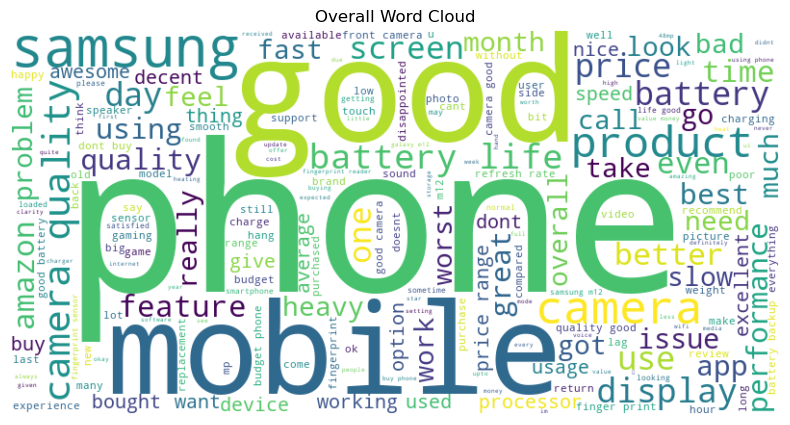

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Concatenate all cleaned reviews for overall word cloud
all_words = ' '.join(reviews['cleaned_review'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud')
plt.show()

# Word Cloud for Positive and Negative Words

## Create Sentiment Column

### Subtask:
Add a new 'sentiment' column to the 'reviews' DataFrame based on the 'rating' column (e.g., rating >= 4 for positive, rating <= 2 for negative, and rating 3 for neutral).


In [6]:
def assign_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

reviews['sentiment'] = reviews['rating'].apply(assign_sentiment)

print("Sentiment distribution:")
print(reviews['sentiment'].value_counts())
display(reviews.head())

Sentiment distribution:
positive    729
negative    512
neutral     199
Name: sentiment, dtype: int64


,title,rating,body,cleaned_review,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,disappointed overall performance samsung,negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,camera quality low,neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",got mobile launch datebattery must appreciated...,positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,1 doesnt work 50ghz wifi frequency 24ghz old s...,negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",worth buyingfaulty software poor display quali...,negative


## Extract Words from Positive Reviews

Filter the DataFrame for positive reviews and concatenate their 'cleaned_review' text.


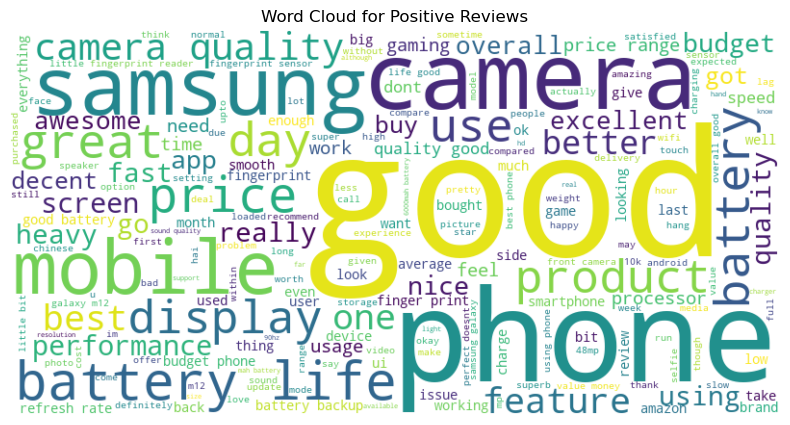

In [7]:
positive_reviews = ' '.join(reviews[reviews['sentiment'] == 'positive']['cleaned_review'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

## Extract Words from Negative Reviews

Filter the DataFrame for negative reviews and concatenate their 'cleaned_review' text.

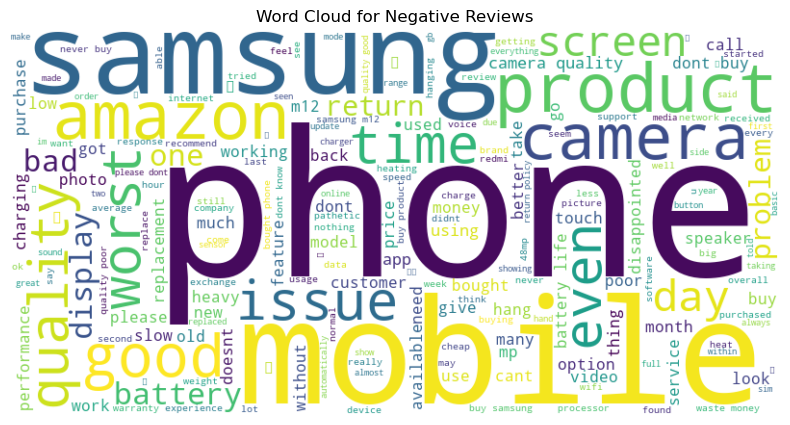

In [8]:
negative_reviews = ' '.join(reviews[reviews['sentiment'] == 'negative']['cleaned_review'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

In [9]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon (if not already downloaded)
try:
    SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')

# Initialize VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_vader_sentiment(text):
    return sia.polarity_scores(text)

# Apply VADER sentiment analysis to the 'cleaned_review' column
reviews['vader_scores'] = reviews['cleaned_review'].apply(get_vader_sentiment)

# Extract individual sentiment scores into separate columns
reviews['vader_neg'] = reviews['vader_scores'].apply(lambda x: x['neg'])
reviews['vader_neu'] = reviews['vader_scores'].apply(lambda x: x['neu'])
reviews['vader_pos'] = reviews['vader_scores'].apply(lambda x: x['pos'])
reviews['vader_compound'] = reviews['vader_scores'].apply(lambda x: x['compound'])

# Display the DataFrame with new VADER sentiment columns
display(reviews[['cleaned_review', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']].head())

,cleaned_review,vader_neg,vader_neu,vader_pos,vader_compound
0,disappointed overall performance samsung,0.508,0.492,0.000,-0.4767
1,camera quality low,0.512,0.488,0.000,-0.2732
2,got mobile launch datebattery must appreciated...,0.078,0.779,0.143,0.3818
3,1 doesnt work 50ghz wifi frequency 24ghz old s...,0.273,0.688,0.039,-0.8472
4,worth buyingfaulty software poor display quali...,0.266,0.668,0.067,-0.6866


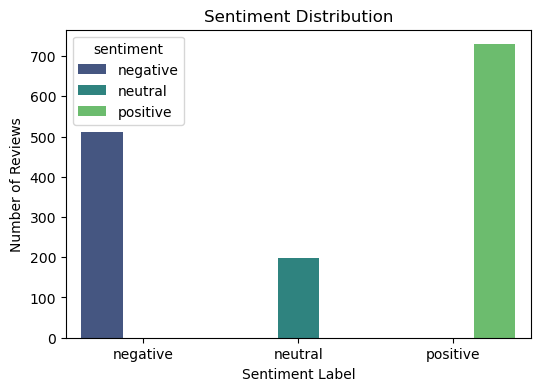

In [10]:
# Plot sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=reviews, hue='sentiment', palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')
plt.show()

# Perform sentiment analysis on the "P625-Dataset.xlsx" dataset by conducting exploratory data analysis.

In [11]:
from collections import Counter

# Function to get most common words from a string of text
def get_most_common_words(text, num_words=10):
    words = text.split()
    word_counts = Counter(words)
    return word_counts.most_common(num_words)

# Get most common words for positive reviews
common_pos_words = get_most_common_words(positive_reviews, 10)
print('Most Common Words in Positive Reviews:')
for word, count in common_pos_words:
    print(f"- {word}: {count}")

print('\n')

# Get most common words for negative reviews
common_neg_words = get_most_common_words(negative_reviews, 10)
print('Most Common Words in Negative Reviews:')
for word, count in common_neg_words:
    print(f"- {word}: {count}")

Most Common Words in Positive Reviews:
- good: 789
- phone: 709
- camera: 490
- battery: 473
- quality: 305
- samsung: 247
- price: 236
- life: 198
- mobile: 167
- also: 157


Most Common Words in Negative Reviews:
- phone: 509
- samsung: 284
- mobile: 232
- camera: 208
- quality: 191
- product: 152
- buy: 146
- amazon: 145
- battery: 138
- dont: 136


# Feature Engineering

Feature Engineering in NLP means converting raw text into meaningful numerical features for understanding Machine Learning Models.

# Tokenization

Breaking text into smaller units(words or sentences)

In [12]:
from nltk.tokenize import word_tokenize

# Download the 'punkt' tokenizer data if not already downloaded
try:
    word_tokenize('test')
except LookupError:
    nltk.download('punkt')

# Apply word_tokenize to the 'cleaned_review' column
reviews['tokenized_review'] = reviews['cleaned_review'].apply(word_tokenize)

# Display the DataFrame with the new column
display(reviews[['cleaned_review', 'tokenized_review']].head())

,cleaned_review,tokenized_review
0,disappointed overall performance samsung,"[disappointed, overall, performance, samsung]"
1,camera quality low,"[camera, quality, low]"
2,got mobile launch datebattery must appreciated...,"[got, mobile, launch, datebattery, must, appre..."
3,1 doesnt work 50ghz wifi frequency 24ghz old s...,"[1, doesnt, work, 50ghz, wifi, frequency, 24gh..."
4,worth buyingfaulty software poor display quali...,"[worth, buyingfaulty, software, poor, display,..."


# Stopword Removal

Removing common words that don’t add much meaning.

Stopword removal has already been performed during the text cleaning and preprocessing phase.
This process occurred when the cleaned_review column was created.
Since the tokenized_review column was derived from cleaned_review, it also reflects the state where stopwords have been removed.

# Lemmatization

Reducing words to their meaningful base form (better than stemming).

In [13]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download necessary NLTK data (if not already downloaded)
try:
    wordnet.lemmas('test')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the 'tokenized_review' column
reviews['lemmatized_review'] = reviews['tokenized_review'].apply(apply_lemmatization)

# Display the DataFrame with the new column for comparison
display(reviews[['cleaned_review', 'tokenized_review', 'lemmatized_review']].head())

,cleaned_review,tokenized_review,lemmatized_review
0,disappointed overall performance samsung,"[disappointed, overall, performance, samsung]","[disappointed, overall, performance, samsung]"
1,camera quality low,"[camera, quality, low]","[camera, quality, low]"
2,got mobile launch datebattery must appreciated...,"[got, mobile, launch, datebattery, must, appre...","[got, mobile, launch, datebattery, must, appre..."
3,1 doesnt work 50ghz wifi frequency 24ghz old s...,"[1, doesnt, work, 50ghz, wifi, frequency, 24gh...","[1, doesnt, work, 50ghz, wifi, frequency, 24gh..."
4,worth buyingfaulty software poor display quali...,"[worth, buyingfaulty, software, poor, display,...","[worth, buyingfaulty, software, poor, display,..."


# Handling Negations

Capturing meaning of words like “not good” properly.

## Implement Negation Handling Function

Create a function to identify negation words and append '_NEG' to subsequent words in a list of tokens.


In [14]:
negation_words = ["not", "no", "never", "don't", "won't", "isn't", "aren't", "couldn't", "wouldn't", "shouldn't", "didn't", "hasn't", "haven't"]
punctuation = list(string.punctuation)

def handle_negations(tokens):
    processed_tokens = []
    negate = False
    for token in tokens:
        # If the token is a punctuation mark, stop negating
        if token in punctuation:
            negate = False
            processed_tokens.append(token)
            continue

        # If the token is a negation word, start negating for subsequent words
        if token in negation_words:
            negate = True
            processed_tokens.append(token)
        elif negate:
            # If negating is active, append _NEG to the word
            processed_tokens.append(token + '_NEG')
        else:
            processed_tokens.append(token)
    return processed_tokens

# Apply the negation handling function to the 'lemmatized_review' column
reviews['negation_handled_review'] = reviews['lemmatized_review'].apply(handle_negations)

# Display the DataFrame with the new column for comparison
display(reviews[['lemmatized_review', 'negation_handled_review']].head())

,lemmatized_review,negation_handled_review
0,"[disappointed, overall, performance, samsung]","[disappointed, overall, performance, samsung]"
1,"[camera, quality, low]","[camera, quality, low]"
2,"[got, mobile, launch, datebattery, must, appre...","[got, mobile, launch, datebattery, must, appre..."
3,"[1, doesnt, work, 50ghz, wifi, frequency, 24gh...","[1, doesnt, work, 50ghz, wifi, frequency, 24gh..."
4,"[worth, buyingfaulty, software, poor, display,...","[worth, buyingfaulty, software, poor, display,..."


# N-Grams Creation

In [15]:
reviews['processed_text_for_ngrams'] = reviews['negation_handled_review'].apply(lambda tokens: ' '.join(tokens))

display(reviews[['negation_handled_review', 'processed_text_for_ngrams']].head())

,negation_handled_review,processed_text_for_ngrams
0,"[disappointed, overall, performance, samsung]",disappointed overall performance samsung
1,"[camera, quality, low]",camera quality low
2,"[got, mobile, launch, datebattery, must, appre...",got mobile launch datebattery must appreciated...
3,"[1, doesnt, work, 50ghz, wifi, frequency, 24gh...",1 doesnt work 50ghz wifi frequency 24ghz old s...
4,"[worth, buyingfaulty, software, poor, display,...",worth buyingfaulty software poor display quali...


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer for bigrams
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2), max_features=10)

# Fit and transform the processed text for bigrams
X_bigram = vectorizer_bigram.fit_transform(reviews['processed_text_for_ngrams'])

print("Top 10 Bigrams:")
print(vectorizer_bigram.get_feature_names_out())

# Initialize CountVectorizer for trigrams
vectorizer_trigram = CountVectorizer(ngram_range=(3, 3), max_features=10)

# Fit and transform the processed text for trigrams
X_trigram = vectorizer_trigram.fit_transform(reviews['processed_text_for_ngrams'])

print("\nTop 10 Trigrams:")
print(vectorizer_trigram.get_feature_names_out())

Top 10 Bigrams:
['battery backup' 'battery life' 'camera quality' 'dont buy'
 'finger print' 'good battery' 'good phone' 'phone good' 'price range'
 'quality good']

Top 10 Trigrams:
['6000 mah battery' 'battery life good' 'camera quality good'
 'camera quality poor' 'finger print reader' 'finger print sensor'
 'good battery life' 'good camera quality' 'medium could loaded'
 'samsung galaxy m12']


# Token Vectorization
Converting text into numbers

Bag of Words

TF-IDF

Word Embeddings

In [17]:
# Bag of Words(BoW)

from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
bow_vectorizer = CountVectorizer()

# Fit and transform the 'cleaned_review' column
X_bow = bow_vectorizer.fit_transform(reviews['cleaned_review'])

print("Shape of Bag of Words feature matrix (X_bow):")
print(X_bow.shape)

# Get feature names (vocabulary)
feature_names = bow_vectorizer.get_feature_names_out()
print("\nSample of Feature Names (first 10):")
print(feature_names[:10])

Shape of Bag of Words feature matrix (X_bow):
(1440, 7511)

Sample of Feature Names (first 10):
['0100' '0100and' '03rd' '05' '05x' '07th' '09th' '0f' '10' '100']


In [18]:
# TF-IDF

# Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features as needed

# Fit and transform the 'cleaned_review' column
X = tfidf_vectorizer.fit_transform(reviews['cleaned_review'])

print("Shape of TF-IDF feature matrix (X):")
print(X.shape)

Shape of TF-IDF feature matrix (X):
(1440, 5000)


In [19]:
print(tfidf_vectorizer.get_feature_names_out())

['0100' '0100and' '03rd' ... 'പൻ' 'യത' 'യല']


In [20]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

In [21]:
tfidf_df

,0100,0100and,03rd,05,05x,07th,09th,0f,10,100,...,തപ,ധന,നടന,നല,പണ,പറഞ,പള,പൻ,യത,യല
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
!pip install gensim

In [23]:
# Word Embedding
from gensim.models import Word2Vec

# Train Word2Vec model on the 'negation_handled_review' column
# The input to Word2Vec should be a list of lists of words
word2vec_model = Word2Vec(sentences=reviews['negation_handled_review'], vector_size=100, window=5, min_count=1, workers=4)

print("Word2Vec model trained successfully!")
print(f"Vocabulary size: {len(word2vec_model.wv)}")

# Display word embedding for a few sample words
sample_words = ['good', 'bad', 'phone', 'battery', 'camera']
print("\nWord embeddings for sample words:")
for word in sample_words:
    if word in word2vec_model.wv:
        print(f"{word}: {word2vec_model.wv[word][:5]}...") # Display first 5 dimensions
    else:
        print(f"'{word}' not in vocabulary.")

Word2Vec model trained successfully!
Vocabulary size: 8249

Word embeddings for sample words:
good: [-0.55521333  0.7372061   0.21142206 -0.08407129  0.30212557]...
bad: [-0.41424453  0.5335557   0.14510663 -0.06553555  0.21796484]...
phone: [-0.73998636  0.98611027  0.28960186 -0.08681589  0.3809168 ]...
battery: [-0.59862155  0.7908768   0.22446805 -0.0877547   0.3155315 ]...
camera: [-0.60109633  0.80923665  0.21555564 -0.10035643  0.3288698 ]...


In [24]:
from sklearn.preprocessing import LabelEncoder

# Initialize a LabelEncoder object.
label_encoder = LabelEncoder()

# Apply the LabelEncoder to the 'sentiment' column to transform its categorical values into numerical representations.
Y = label_encoder.fit_transform(reviews['sentiment'])

print("Shape of features (X):", X.shape)
print("Shape of target (y):", Y.shape)
print("Encoded target variable (y) sample:", Y[:5])
print("Original sentiment labels:", reviews['sentiment'].head().tolist())
print("Mapping of sentiment labels to numerical values:", list(label_encoder.classes_))


Shape of features (X): (1440, 5000)
Shape of target (y): (1440,)
Encoded target variable (y) sample: [0 1 2 0 0]
Original sentiment labels: ['negative', 'neutral', 'positive', 'negative', 'negative']
Mapping of sentiment labels to numerical values: ['negative', 'neutral', 'positive']


## **Task 2- Model Building & Model Evaluation**

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Using a common split ratio like 80% for training and 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

print("\nDistribution of sentiment in y_train:")
unique_train, counts_train = np.unique(Y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"Label {label}: {count} samples")

print("\nDistribution of sentiment in y_test:")
unique_test, counts_test = np.unique(Y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"Label {label}: {count} samples")

Shape of X_train: (1152, 5000)
Shape of X_test: (288, 5000)
Shape of Y_train: (1152,)
Shape of Y_test: (288,)

Distribution of sentiment in y_train:
Label 0: 410 samples
Label 1: 159 samples
Label 2: 583 samples

Distribution of sentiment in y_test:
Label 0: 102 samples
Label 1: 40 samples
Label 2: 146 samples


### Logistic Regression Model



In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Train the model
lr.fit(X_train, Y_train)
print("Logistic Regression model trained successfully.")

# Make predictions on the test set
Y_pred_lr = lr.predict(X_test)

# Evaluate the model's performance
print("\nLogistic Regression Model Evaluation ")

# Accuracy Score
accuracy = accuracy_score(Y_test, Y_pred_lr)
print(f"Accuracy Score: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_lr, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_lr))

Logistic Regression model trained successfully.

Logistic Regression Model Evaluation 
Accuracy Score: 0.7708

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79       102
     neutral       1.00      0.03      0.05        40
    positive       0.76      0.96      0.85       146

    accuracy                           0.77       288
   macro avg       0.85      0.59      0.56       288
weighted avg       0.80      0.77      0.72       288


Confusion Matrix:
[[ 81   0  21]
 [ 16   1  23]
 [  6   0 140]]


### Support Vector Machine(SVM) Model

In [27]:
from sklearn.svm import SVC

svm= SVC(kernel='linear', random_state=42, class_weight='balanced')

# Train the model
svm.fit(X_train, Y_train)
print("SVM model trained successfully.")

# Make predictions on the test set
Y_pred_svm = svm.predict(X_test)

# Evaluate the model's performance
print("\n SVM Model Evaluation")

# Accuracy Score
accuracy_svm = accuracy_score(Y_test, Y_pred_svm)
print(f"Accuracy Score: {accuracy_svm:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_svm, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_svm))

SVM model trained successfully.

 SVM Model Evaluation
Accuracy Score: 0.7604

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.80      0.79       102
     neutral       0.31      0.25      0.28        40
    positive       0.85      0.87      0.86       146

    accuracy                           0.76       288
   macro avg       0.64      0.64      0.64       288
weighted avg       0.75      0.76      0.75       288


Confusion Matrix:
[[ 82  12   8]
 [ 15  10  15]
 [  9  10 127]]


### XG Boost Model

In [28]:
import xgboost as xgb

xgb = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_), 
                            eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Train the model
xgb.fit(X_train, Y_train)
print("XGBoost Classifier model trained successfully.")

# Make predictions on the test set
Y_pred_xgb = xgb.predict(X_test)

# Evaluate the model's performance
print("\nXGBoost Classifier Model Evaluation")

# Accuracy Score
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
print(f"Accuracy Score: {accuracy_xgb:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_xgb, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_xgb))

C:\Users\DELL\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:06:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier model trained successfully.

XGBoost Classifier Model Evaluation
Accuracy Score: 0.7465

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.78      0.77       102
     neutral       0.30      0.07      0.12        40
    positive       0.77      0.90      0.83       146

    accuracy                           0.75       288
   macro avg       0.61      0.59      0.57       288
weighted avg       0.70      0.75      0.71       288


Confusion Matrix:
[[ 80   3  19]
 [ 17   3  20]
 [ 10   4 132]]


### Multinomial Naive Bayes Model

In [29]:
from sklearn.naive_bayes import MultinomialNB

# Instantiate a Multinomial Naive Bayes model
mnb = MultinomialNB()

# Train the model
mnb.fit(X_train, Y_train)
print("Multinomial Naive Bayes model trained successfully.")

# Make predictions on the test set
Y_pred_mnb = mnb.predict(X_test)

# Evaluate the model's performance
print("\nMultinomial Naive Bayes Model Evaluation")

# Accuracy Score
accuracy_mnb = accuracy_score(Y_test, Y_pred_mnb)
print(f"Accuracy Score: {accuracy_mnb:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_mnb, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_mnb))

Multinomial Naive Bayes model trained successfully.

Multinomial Naive Bayes Model Evaluation
Accuracy Score: 0.7083

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.61      0.71       102
     neutral       0.00      0.00      0.00        40
    positive       0.66      0.97      0.78       146

    accuracy                           0.71       288
   macro avg       0.51      0.53      0.50       288
weighted avg       0.64      0.71      0.65       288


Confusion Matrix:
[[ 62   0  40]
 [  6   0  34]
 [  4   0 142]]


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Random Forest Model

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instantiate a Random Forest Classifier model
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, Y_train)
print("Random Forest Classifier model trained successfully.")

# Make predictions on the test set
Y_pred_rf = rf.predict(X_test)

# Evaluate the model's performance
print("\n Random Forest Classifier Model Evaluation")

# Accuracy Score
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
print(f"Accuracy Score: {accuracy_rf:.4f}")

# Classification Report (with zero_division parameter to handle warnings)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf, target_names=label_encoder.classes_, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_rf))

Random Forest Classifier model trained successfully.

 Random Forest Classifier Model Evaluation
Accuracy Score: 0.7326

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75       102
     neutral       0.00      0.00      0.00        40
    positive       0.73      0.92      0.81       146

    accuracy                           0.73       288
   macro avg       0.49      0.56      0.52       288
weighted avg       0.63      0.73      0.68       288


Confusion Matrix:
[[ 76   0  26]
 [ 15   0  25]
 [ 11   0 135]]


In [31]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

# Initialize a dictionary to store performance metrics
performance_metrics = {}

models = {
    'Logistic Regression': Y_pred_lr,
    'Multinomial Naive Bayes': Y_pred_mnb,
    'SVM': Y_pred_svm,
    'XGBoost': Y_pred_xgb,
    'Random Forest': Y_pred_rf
}

# Iterate through each model to collect metrics
for model_name, y_pred in models.items():
    accuracy = accuracy_score(Y_test, y_pred)
    # Get precision, recall, f1-score for each class
    precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, y_pred, average=None, labels=np.unique(Y_test))

    # Store metrics, mapping them back to original sentiment labels
    metrics_dict = {
        'Accuracy': accuracy,
    }

    for i, label_id in enumerate(np.unique(Y_test)):
        sentiment_label = label_encoder.inverse_transform([label_id])[0]
        metrics_dict[f'Precision ({sentiment_label})'] = precision[i]
        metrics_dict[f'Recall ({sentiment_label})'] = recall[i]
        metrics_dict[f'F1-score ({sentiment_label})'] = f1_score[i]

    performance_metrics[model_name] = metrics_dict

# Create a DataFrame from the collected metrics
metrics_df = pd.DataFrame(performance_metrics).T

print("\n--- Model Performance Comparison ---")
display(metrics_df.round(4))



--- Model Performance Comparison ---


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,Accuracy,Precision (negative),Recall (negative),F1-score (negative),Precision (neutral),Recall (neutral),F1-score (neutral),Precision (positive),Recall (positive),F1-score (positive)
Logistic Regression,0.7708,0.7864,0.7941,0.7902,1.0000,0.025,0.0488,0.7609,0.9589,0.8485
Multinomial Naive Bayes,0.7083,0.8611,0.6078,0.7126,0.0000,0.000,0.0000,0.6574,0.9726,0.7845
SVM,0.7604,0.7736,0.8039,0.7885,0.3125,0.250,0.2778,0.8467,0.8699,0.8581
XGBoost,0.7465,0.7477,0.7843,0.7656,0.3000,0.075,0.1200,0.7719,0.9041,0.8328
Random Forest,0.7326,0.7451,0.7451,0.7451,0.0000,0.000,0.0000,0.7258,0.9247,0.8133


In [33]:
import pickle

models = {
    "lr": lr,
    "svm": svm,
    "rf": rf,
    "xgb": xgb,
    "mnb":mnb
}

pickle.dump(models, open("sentiment_models.pkl", "wb"))